In [25]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import torch
from model.MinAggGNN import MinAggGNN
import matplotlib.pyplot as plt

device = torch.device('cuda')
L = 2
m = 2
epochs = 20000
eta = 0.001
seed = 0

model = MinAggGNN(1, 8, L, 1, edge_dim = 1)
state_dict = torch.load(f'../model_progress/bellman_ford/seed_{seed}/model_final.pt')
model.load_state_dict(state_dict)
model.eval()
model.to(device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


MinAggGNN(1, 1, num_layers=2)

In [26]:
from MINAR.ComputationGraph import ComputationGraph, Circuit
from model.CustomLosses import MultiplicativeLoss
import torch_geometric as pyg
import networkx as nx

G = ComputationGraph(model)
G.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
G.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
G.number_of_edges()

18240

In [27]:
test_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
criterion = MultiplicativeLoss()
mse_criterion = torch.nn.MSELoss()
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])

In [28]:
corrupted_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
for data_corr in corrupted_data:
    data_corr.x = torch.zeros_like(data_corr.x, device=device)
    data_corr.x[0] = 0.
    data_corr.edge_attr = torch.zeros_like(data_corr.edge_attr, device=device)

G.calculate_scores(test_data, corrupted_data, mse_criterion, which = 'weight_grad')
G.calculate_scores(test_data, corrupted_data, mse_criterion, which = 'EAP')
G.calculate_scores(test_data, corrupted_data, mse_criterion, which = 'EAP-IG', steps=20)

In [9]:
# which = 'weight'
# which = 'weight_grad'
# which = 'EAP'
which = 'EAP-IG'
K = 10
C = Circuit(model, G, K=K, key=which)
print(C.number_of_edges())

10


In [10]:
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
for data in test_loader:
    out = C.forward(data)
    mul_circuit_loss = float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss = float(mse_criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Circuit Test Loss: {mul_circuit_loss:.4f}')
    print(f'Circuit Test MSE Loss: {mse_circuit_loss:.4f}')

Circuit Test Loss: 0.0545
Circuit Test MSE Loss: 0.0000


In [11]:
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])
for data in test_loader:
    out = C.ablate_circuit(data)
    mul_circuit_loss = float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss = float(mse_criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Circuit Test Loss: {mul_circuit_loss:.4f}')
    print(f'Circuit Test MSE Loss: {mse_circuit_loss:.4f}')

Circuit Test Loss: 21870.6836
Circuit Test MSE Loss: 0.0015


In [12]:
import matplotlib
from matplotlib import colors, cm
import matplotlib.pyplot as plt

from IPython.display import display
from PIL import Image

matplotlib.rcParams.update({'font.family':'serif'})

nx.relabel_nodes(C, {'edge_attr' : 'edge_weight',
                     'input.0' : 'x',
                     'convs.1.up_mlp.lins.1.0' : 'output'},
                     copy=False)
C_pydot = nx.nx_agraph.to_agraph(C)
C_pydot.node_attr['shape'] = 'box'
C_pydot.node_attr['style'] = 'rounded, filled'

layer_colors = ['white', '#c6dbef', '#c6dbef', '#fdd0a2', '#fdd0a2', '#c6dbef', '#c6dbef', '#fdd0a2', 'white']
node_colors = {node : layer_colors[layer] for node, layer in nx.get_node_attributes(C, 'layer').items()}
for v in C_pydot.nodes():
    node = C_pydot.get_node(v)
    node.attr['fillcolor'] = node_colors[node]

edge_cmap=plt.cm.coolwarm
_, circuit_edge_weights = zip(*nx.get_edge_attributes(C,'weight').items())
abs_vmax = abs(max(circuit_edge_weights, key=abs))
normalized_weights = {edge : weight / (2*abs_vmax) + 0.5 for edge, weight in nx.get_edge_attributes(C,'weight').items()}
for u,v in C_pydot.edges():
    edge = C_pydot.get_edge(u,v)
    edge.attr['color'] = colors.to_hex(edge_cmap(normalized_weights[edge]))
    edge.attr["penwidth"] = 3.0

if seed == 0:
    spine = ['x',
            'convs.0.agg_mlp.lins.0.58',
            'convs.0.agg_mlp.lins.1.17',
            'convs.0.up_mlp.lins.0.14',
            'convs.0.up_mlp.lins.1.2',
            'convs.1.agg_mlp.lins.0.5',
            'convs.1.agg_mlp.lins.1.55',
            'convs.1.up_mlp.lins.0.5',
            'output']
    for i in range(len(spine)-1):
        edge = C_pydot.get_edge(spine[i],spine[i+1])
        edge.attr['weight'] = 100

C_pydot.graph_attr['nodesep'] = '.5'
C_pydot.graph_attr['splines'] = 'true'
C_pydot.graph_attr['dpi'] = 300
# C_pydot.draw(f"../images/bellman_ford_circuit_seed_{seed}.pdf", prog="dot")
C_pydot.draw(f"../images/bellman_ford_circuit_seed_{seed}.png", prog="dot")
# C_pydot.write(f"../dot_files/bellman_ford_circuit_seed_{seed}.dot")
# display(Image.open(f"../images/bellman_ford_circuit_seed_{seed}.png"))

C:\Users\heje197\AppData\Local\Temp\ipykernel_15316\2730871364.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


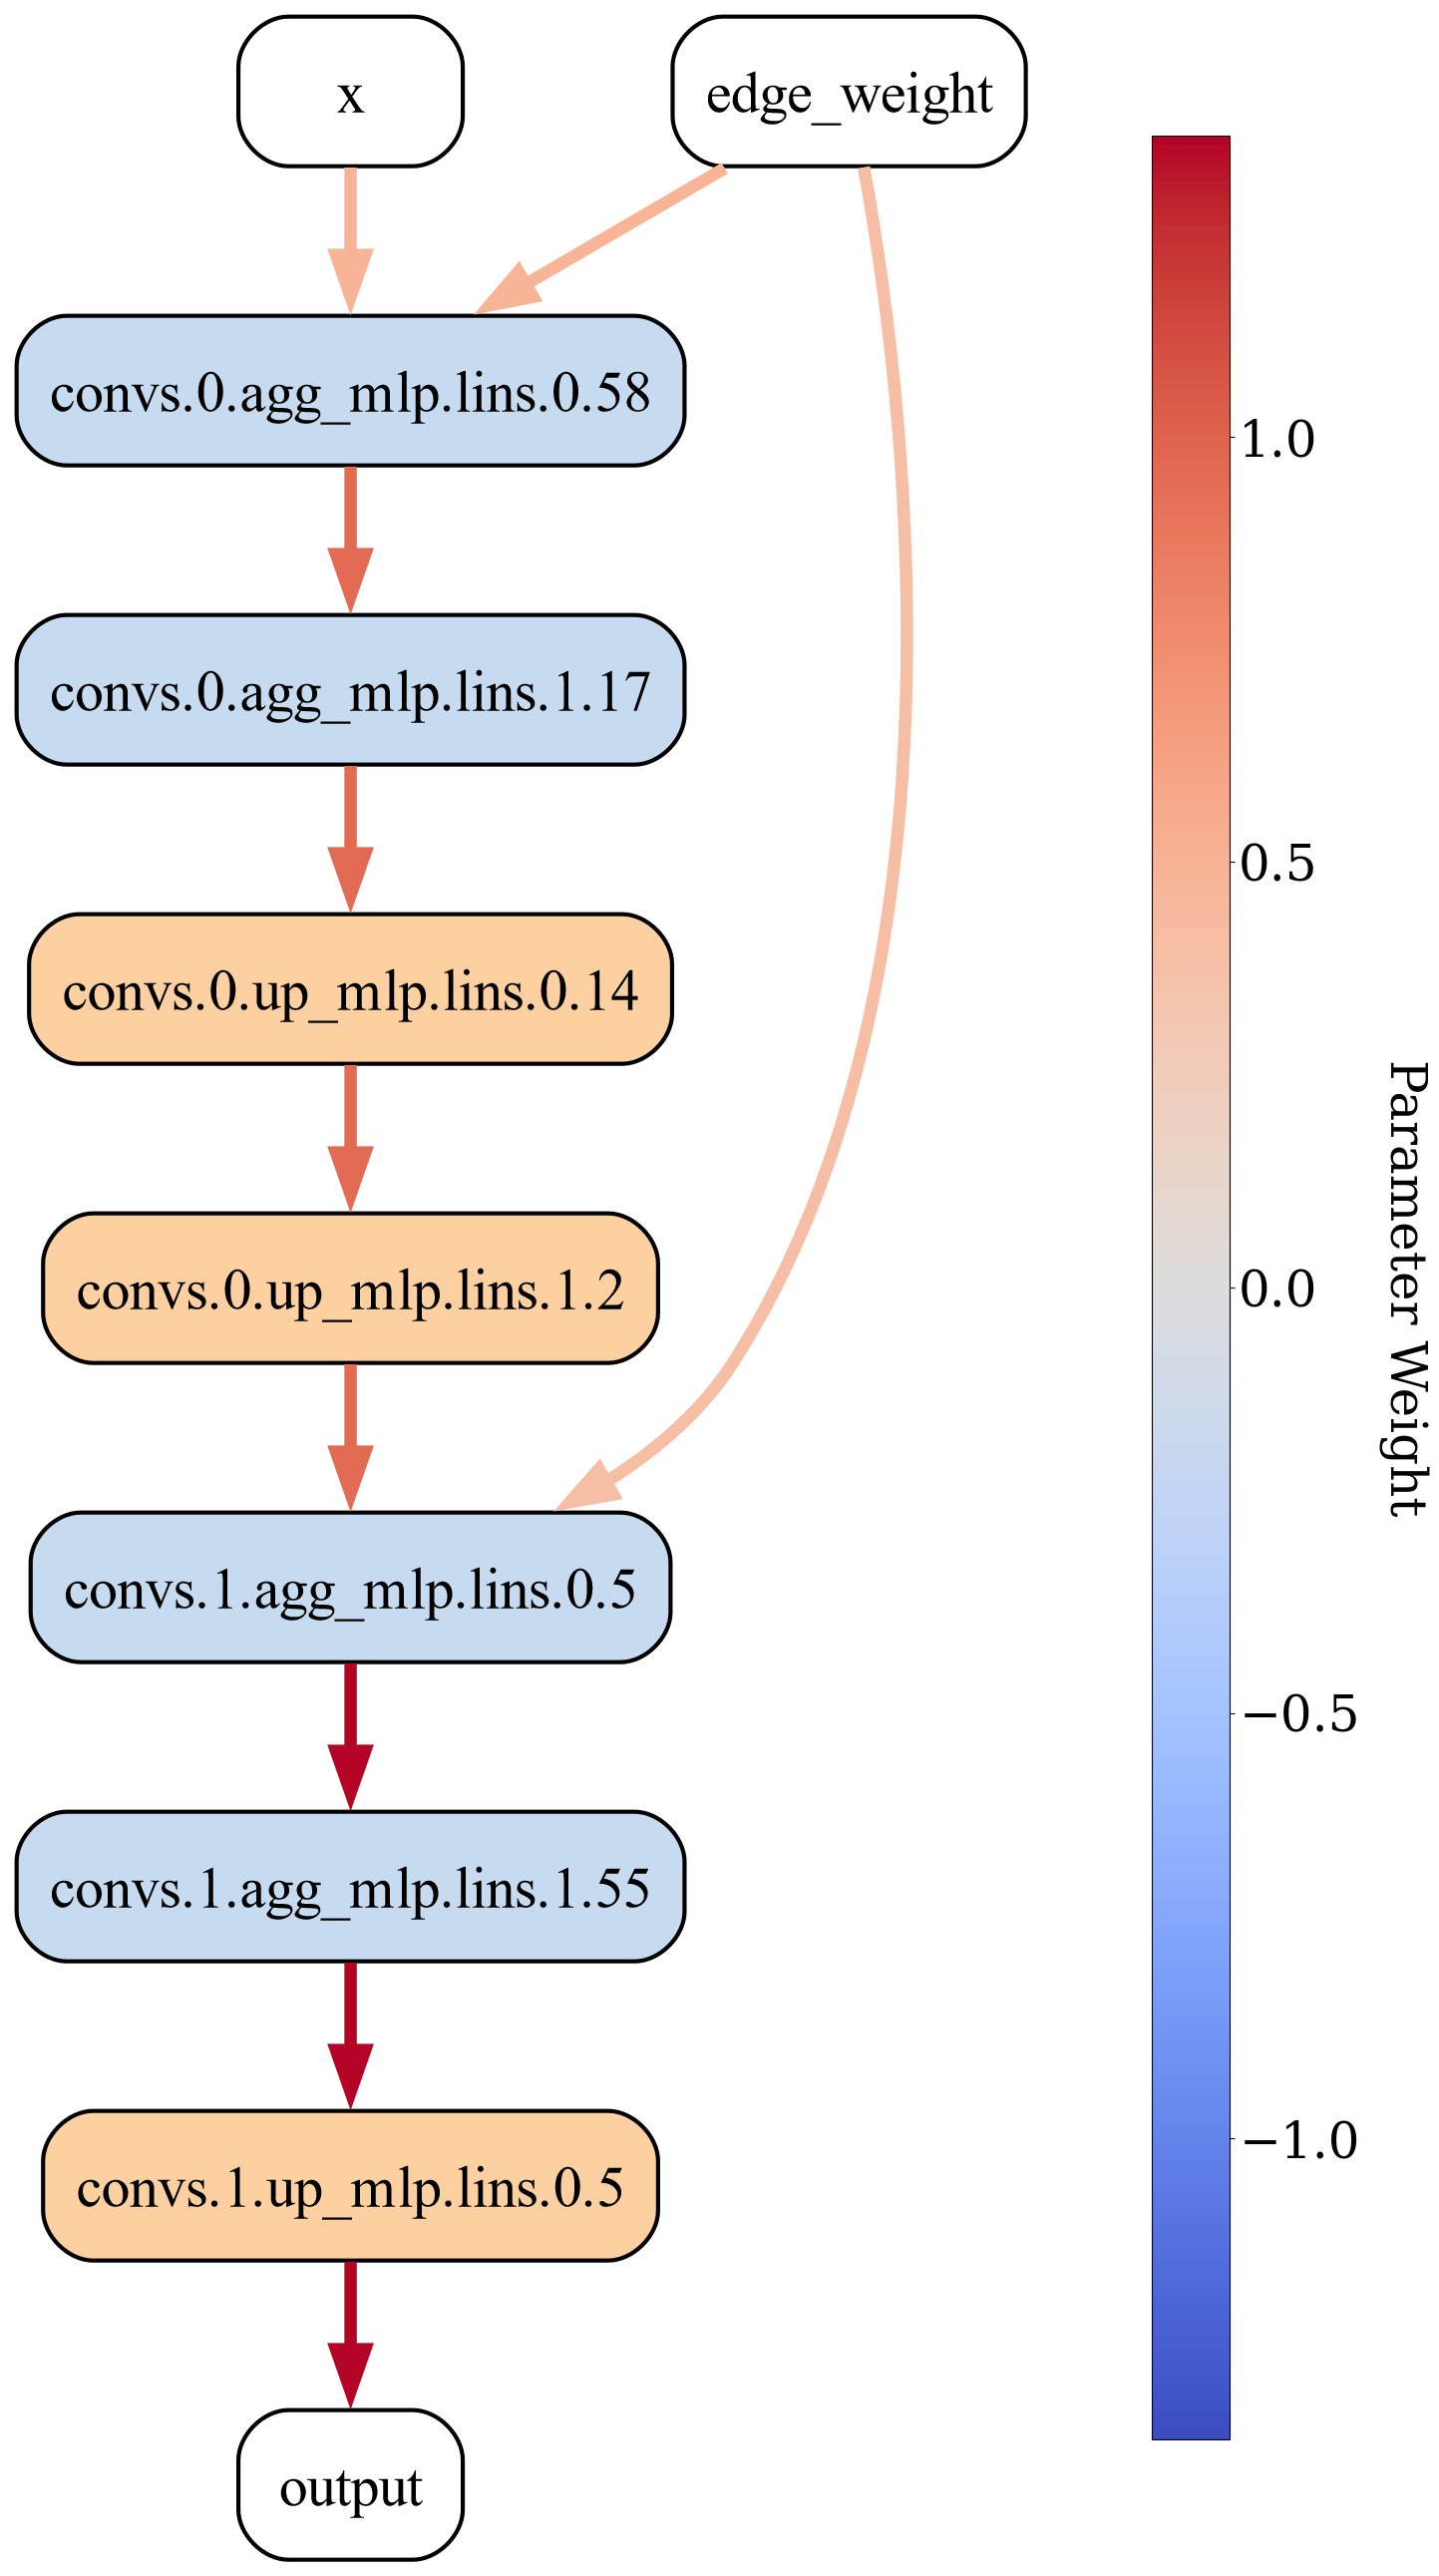

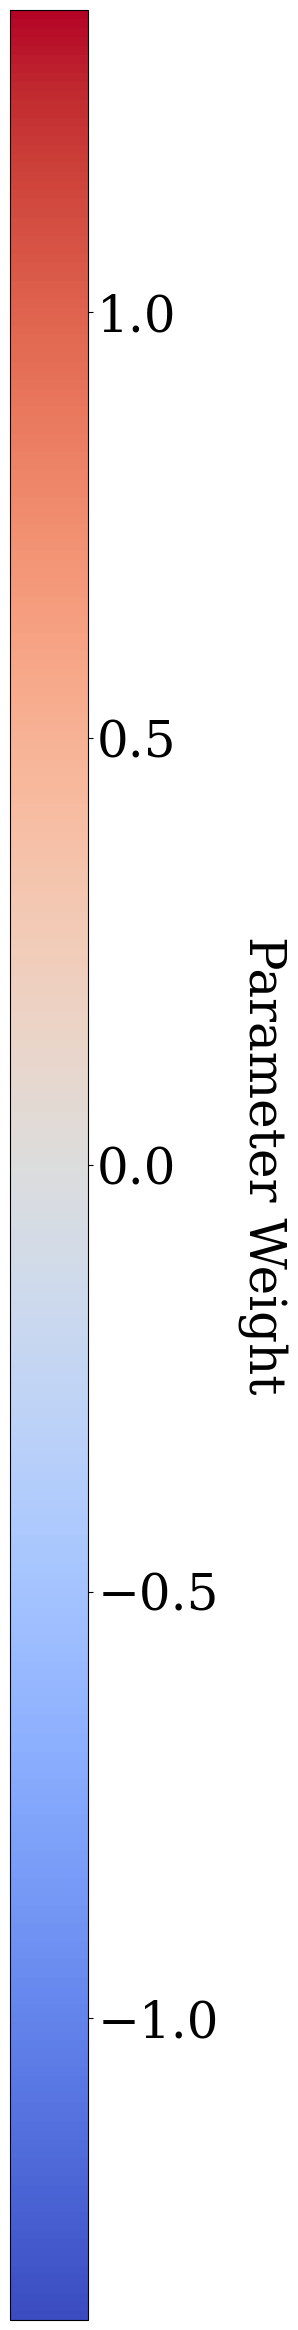

In [13]:
# create and display a standalone colorbar for the circuit edge colors    
matplotlib.rcParams.update({'font.size':36})
max_edge_weight = max(circuit_edge_weights, key=abs)
vmin, vmax = -float(max_edge_weight), float(max_edge_weight)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap=edge_cmap, norm=norm)
sm.set_array([])

fig_cb, ax_cb = plt.subplots(figsize=(1, 30))
fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical').set_label('Parameter Weight', rotation=270, labelpad=50)
plt.tight_layout()
plt.savefig(f"../images/bellman_ford_circuit_colorbar_seed_{seed}.pdf", bbox_inches='tight')
plt.savefig(f"../images/bellman_ford_circuit_colorbar_seed_{seed}.png", bbox_inches='tight')

circuit_image = Image.open(f"../images/bellman_ford_circuit_seed_{seed}.png")
colorbar_image = Image.open(f"../images/bellman_ford_circuit_colorbar_seed_{seed}.png")
colorbar_y = (circuit_image.height - colorbar_image.height) // 2
padding = 100
combined_w = circuit_image.width + padding + colorbar_image.width
combined_image = Image.new('RGBA', (combined_w, circuit_image.height), (255, 255, 255, 255))

combined_image.paste(circuit_image, (0, 0))
combined_image.paste(colorbar_image, (circuit_image.width + padding, colorbar_y))

combined_image = combined_image.convert('RGB')  # drop alpha for saving/display
combined_image.save(f"../images/bellman_ford_circuit_with_colorbar_seed_{seed}.png", dpi=(300,300))
display(combined_image)

In [10]:
C = Circuit(model, G, K=K, key=which)

checkpoints = torch.load(f'../model_progress/bellman_ford/seed_{seed}/model_checkpoints.pt')
try:
    circuit_losses = torch.load(f'../model_progress/bellman_ford/seed_{seed}/circuit_losses.pt')
    circuit_mse_losses = torch.load(f'../model_progress/bellman_ford/seed_{seed}/circuit_mse_losses.pt')
    circuit_l1_norms = torch.load(f'../model_progress/bellman_ford/seed_{seed}/circuit_l1_norms.pt')
    print('Loaded existing circuit progress data.')
except:
    circuit_losses = []
    circuit_mse_losses = []
    circuit_l1_norms = torch.zeros(len(checkpoints))
    for i, checkpoint in enumerate(checkpoints):
        model.load_state_dict(checkpoint)
        C.model_state_dict = checkpoint
        for data in test_loader:
            G_tmp = ComputationGraph(model)
            G_tmp.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
                'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
            G_tmp.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
            G_tmp.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
            for e in C.edges:
                circuit_l1_norms[i] += float(G_tmp.edges[e]['weight'])
            circuit_out = C.forward(data).flatten()
            circuit_losses.append(float(criterion(circuit_out[data.reachable], data.y[data.reachable]).detach() / num_reachable_test_nodes))
            circuit_mse_losses.append(float(mse_criterion(circuit_out[data.reachable], data.y[data.reachable]).detach() / num_reachable_test_nodes))
    torch.save(circuit_losses, f'../model_progress/bellman_ford/seed_{seed}/circuit_losses.pt')
    torch.save(circuit_mse_losses, f'../model_progress/bellman_ford/seed_{seed}/circuit_mse_losses.pt')
    torch.save(circuit_l1_norms, f'../model_progress/bellman_ford/seed_{seed}/circuit_l1_norms.pt')

Loaded existing circuit progress data.


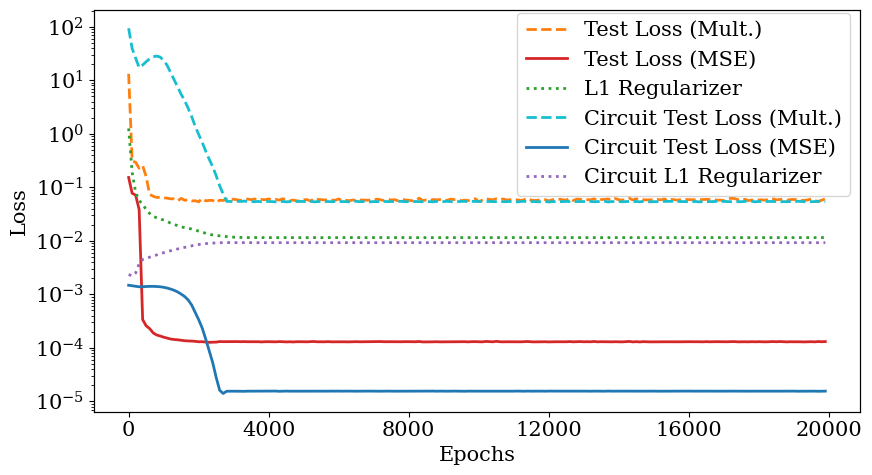

In [11]:
from matplotlib.patches import ConnectionPatch, Rectangle
test_losses = torch.load(f'../model_progress/bellman_ford/seed_{seed}/test_losses.pt')
mse_losses = torch.load(f'../model_progress/bellman_ford/seed_{seed}/mse_losses.pt')
l1_regs = torch.load(f'../model_progress/bellman_ford/seed_{seed}/l1_regs.pt')

plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'serif'
plt.rcParams['lines.linewidth'] = 2

# prepare numpy arrays for plotting (safe for gpu tensors)
test_losses_np = test_losses[0:epochs:100].detach().cpu().numpy()
mse_losses_np = mse_losses[0:epochs:100].detach().cpu().numpy()
l1_regs_np = (eta * l1_regs)[0:epochs:100].detach().cpu().numpy()

circuit_losses_np = np.array(circuit_losses)
circuit_mse_np = np.array(circuit_mse_losses)
circuit_l1_np = (eta * circuit_l1_norms).detach().cpu().numpy()

num_ticks = 5

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

# primary curves (test losses)
ax.plot(test_losses_np, label='Test Loss (Mult.)', color='tab:orange', ls='dashed')
ax.plot(mse_losses_np, label='Test Loss (MSE)', color='tab:red', ls='solid')
ax.plot(l1_regs_np, label='L1 Regularizer', color='tab:green', ls='dotted')

# secondary axis (top x-axis) for circuit quantities (different x-scale)
ax2 = ax.twiny()
ax2.plot(circuit_losses_np, color='tab:cyan', label='Circuit Test Loss (Mult.)', ls='dashed')
ax2.plot(circuit_mse_np, color='tab:blue', label='Circuit Test Loss (MSE)', ls='solid')
ax2.plot(circuit_l1_np, color='tab:purple', label='Circuit L1 Regularizer', ls='dotted')

# ticks and labels
ax.set_xticks(range(0, len(circuit_losses_np) + 1, max(1, len(circuit_losses_np) // num_ticks)))
ax.set_xticklabels(range(0, epochs + 1, max(1, epochs // num_ticks)))
ax2.set_xticks([])

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_yscale('log')

# add legend (combined)
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(.97, .97), loc='upper right')

plt.tight_layout()
plt.savefig(f'../images/circuits_bellman_ford_grokking_seed_{seed}.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
from tqdm import tqdm
def find_best_K(G, model, test_loader, which='EAP-IG', max_K=100, eps=1e-3, verbose=True):
    best_loss = np.inf
    best_K = -1
    Ks = range(max_K+1)
    if verbose:
        Ks = tqdm(Ks)
    for K in Ks:
        C_tmp = Circuit(model, G, K=K, key=which)
        total_loss = 0.0
        for data in test_loader:
            out = C_tmp.forward(data)
            total_loss += float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
        if total_loss < best_loss - eps:
            best_loss = total_loss
            best_K = K
            if verbose:
                Ks.set_description(f'Best K: {best_K}, Loss: {best_loss:.4f}')
    return best_K

In [40]:
checkpoints = torch.load(f'../model_progress/bellman_ford/seed_{seed}/model_checkpoints.pt')
idx = 1
check_epochs = [1000, 2000, 3000]
check_epoch = check_epochs[idx]
checkpoint_idx = check_epoch // 100 - 1
checkpoint_mid = checkpoints[checkpoint_idx]

model.load_state_dict(checkpoint_mid)
model.eval()

G_mid = ComputationGraph(model)
G_mid.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
G_mid.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G_mid.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
G_mid.calculate_scores(test_data, corrupted_data, mse_criterion, which = 'EAP-IG', steps=20)

In [41]:
K = find_best_K(G_mid, model, test_loader, which='EAP-IG')
print(f'Best K: {K}')
C_mid = Circuit(model, G_mid, K=K, key='EAP-IG')
print(C_mid.number_of_edges())
for data in test_loader:
    out = C_mid.forward(data)
    mul_circuit_loss = float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss = float(mse_criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Circuit Test Loss: {mul_circuit_loss:.4f}')
    print(f'Circuit Test MSE Loss: {mse_circuit_loss:.4f}')

Best K: 31, Loss: 0.0565: 100%|██████████| 101/101 [00:58<00:00,  1.71it/s]   


Best K: 31
29
Circuit Test Loss: 0.0565
Circuit Test MSE Loss: 0.0000


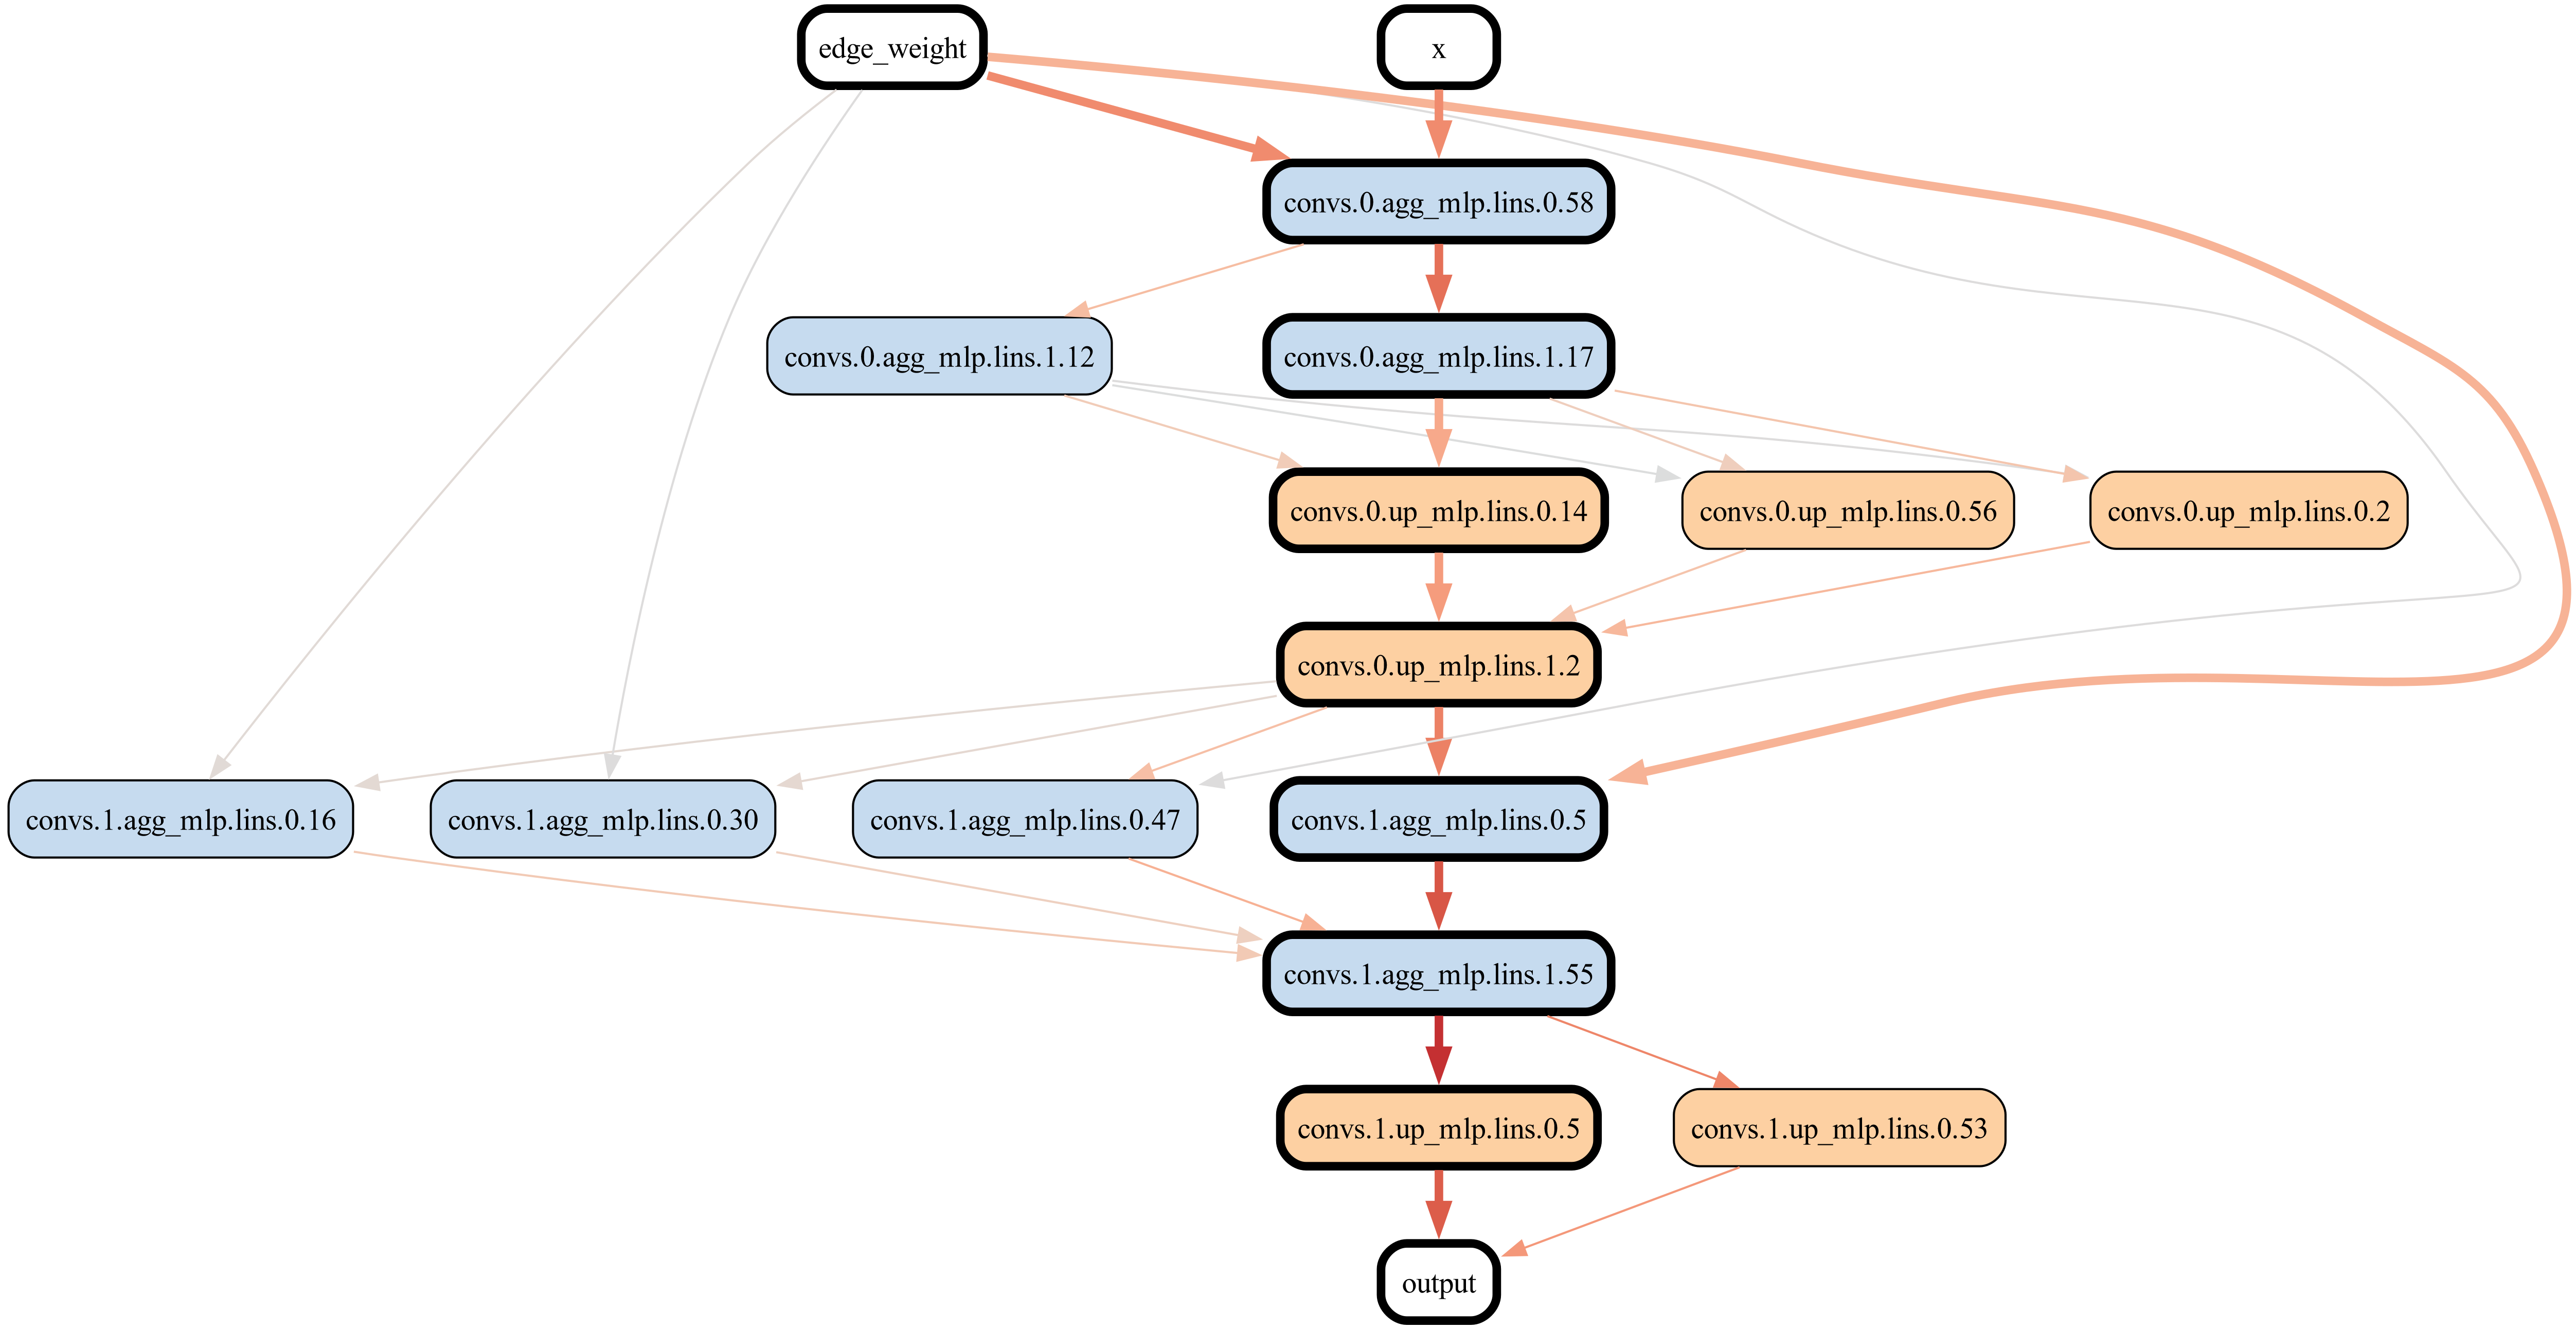

In [42]:
from IPython.display import display
from PIL import Image
nx.relabel_nodes(C_mid, {'edge_attr' : 'edge_weight',
                     'input.0' : 'x',
                     'convs.1.up_mlp.lins.1.0' : 'output'},
                     copy=False)
C_mid_pydot = nx.nx_agraph.to_agraph(C_mid)
C_mid_pydot.node_attr['shape'] = 'box'
C_mid_pydot.node_attr['style'] = 'rounded, filled'

layer_colors = ['white', '#c6dbef', '#c6dbef', '#fdd0a2', '#fdd0a2', '#c6dbef', '#c6dbef', '#fdd0a2', 'white']
node_colors = {node : layer_colors[layer] for node, layer in nx.get_node_attributes(C_mid, 'layer').items()}
for v in C_mid_pydot.nodes():
    node = C_mid_pydot.get_node(v)
    node.attr['fillcolor'] = node_colors[node]
    if node in C_pydot.nodes():
        node.attr['style'] = 'rounded, filled, bold'
        node.attr['penwidth'] = 4.0

edge_cmap=plt.cm.coolwarm
_, circuit_edge_weights = zip(*nx.get_edge_attributes(C_mid,'weight').items())
# abs_vmax = abs(max(circuit_edge_weights, key=abs))
normalized_weights = {edge : weight / (2*abs_vmax) + 0.5 for edge, weight in nx.get_edge_attributes(C_mid,'weight').items()}
for u,v in C_mid_pydot.edges():
    edge = C_mid_pydot.get_edge(u,v)
    edge.attr['color'] = colors.to_hex(edge_cmap(normalized_weights[edge]))
    edge.attr["penwidth"] = 1.0
    if edge in C_pydot.edges():
        edge.attr["penwidth"] = 4.0

spine = ['x',
         'convs.0.agg_mlp.lins.0.58',
         'convs.0.agg_mlp.lins.1.17',
         'convs.0.up_mlp.lins.0.14',
         'convs.0.up_mlp.lins.1.2',
         'convs.1.agg_mlp.lins.0.5',
         'convs.1.agg_mlp.lins.1.55',
         'convs.1.up_mlp.lins.0.5',
         'output']
for i in range(len(spine)-1):
    edge = C_mid_pydot.get_edge(spine[i],spine[i+1])
    edge.attr['weight'] = 100

C_mid_pydot.graph_attr['nodesep'] = '.5'
C_mid_pydot.graph_attr['splines'] = 'true'
C_mid_pydot.graph_attr['dpi'] = 300
C_mid_pydot.draw(f"../images/bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.pdf", prog="dot")
C_mid_pydot.draw(f"../images/bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.png", prog="dot")
display(Image.open(f"../images/bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.png"))

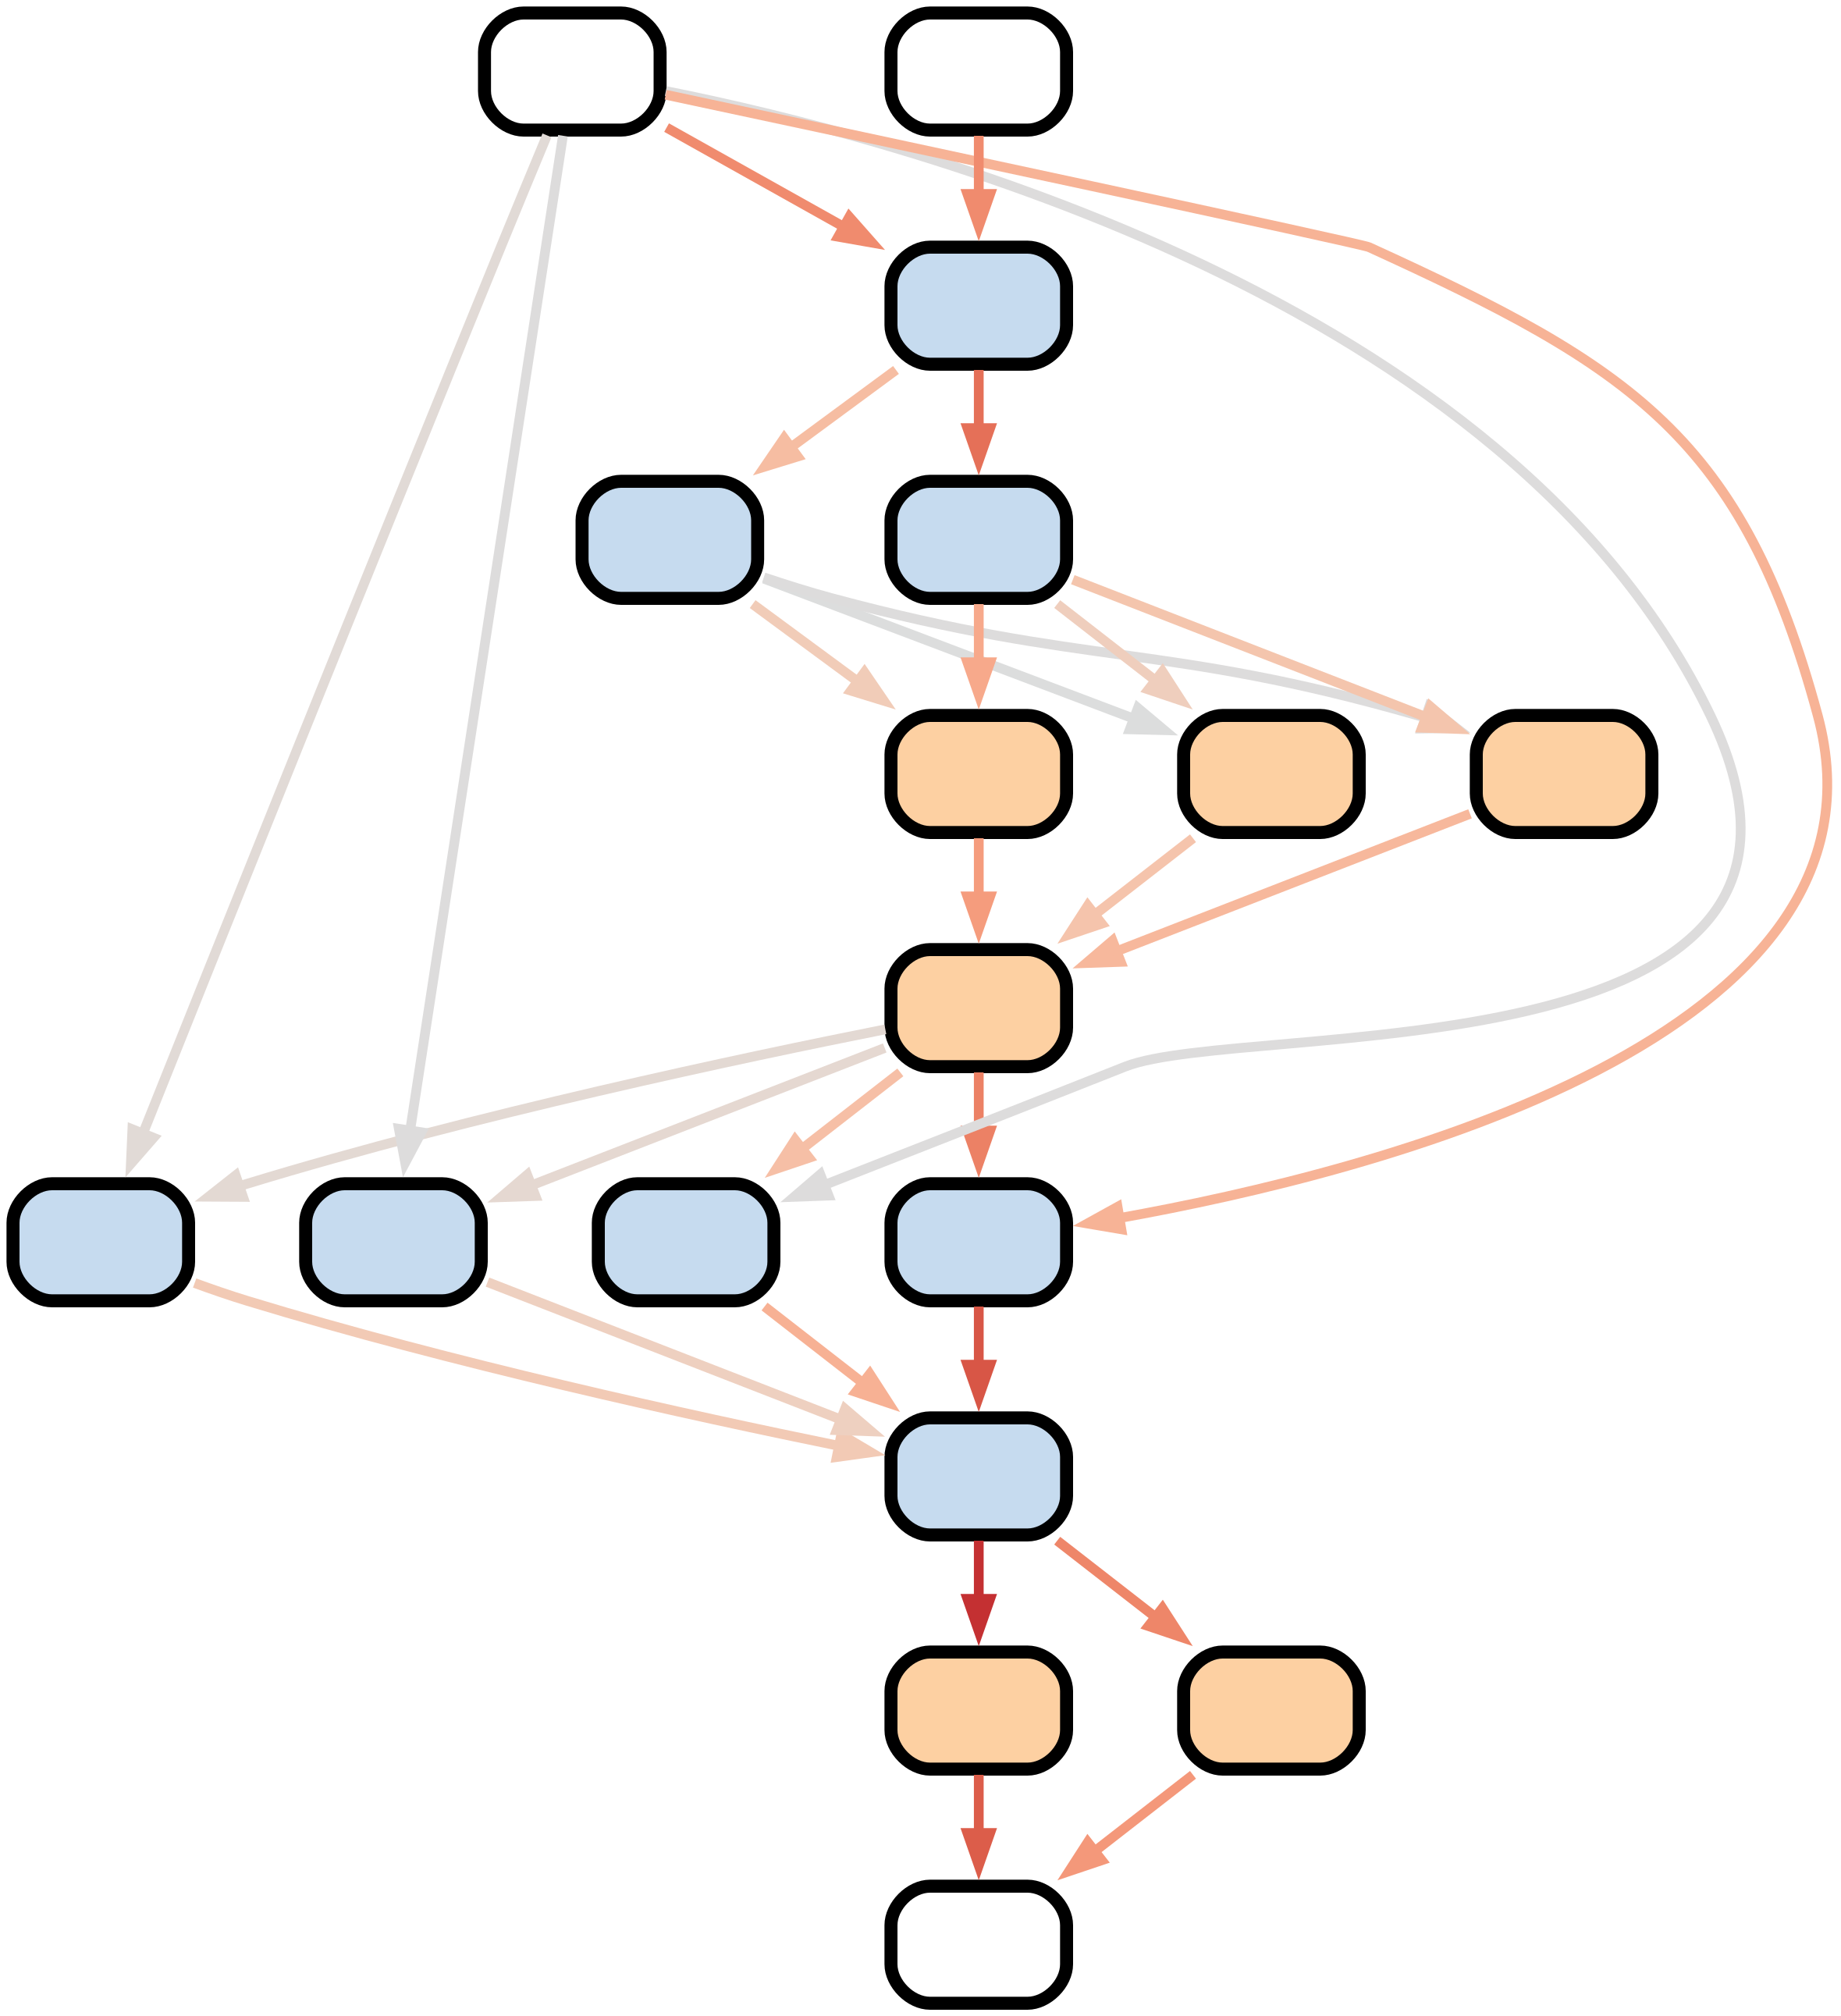

In [43]:
C_mid_small = C_mid_pydot.copy()
for v in C_mid_small.nodes():
    node = C_mid_small.get_node(v)
    node.attr['fillcolor'] = node_colors[node]
    node.attr['style'] = 'rounded, filled, bold'
    node.attr['penwidth'] = 4.0
    node.attr['label'] = ""
C_mid_small.node_attr['style'] = 'rounded, filled'
for u,v in C_mid_small.edges():
    edge = C_mid_small.get_edge(u,v)
    edge.attr["penwidth"] = 3.0

C_mid_small.graph_attr['nodesep'] = '.5'
C_mid_small.graph_attr['splines'] = 'true'
C_mid_small.graph_attr['dpi'] = 300
C_mid_small.draw(f"../images/poster_bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.pdf", prog="dot")
C_mid_small.draw(f"../images/poster_bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.png", prog="dot")
display(Image.open(f"../images/poster_bellman_ford_circuit_epoch_{check_epoch}_seed_{seed}.png"))

In [29]:
from tqdm import tqdm
model.load_state_dict(state_dict)
mse_criterion = torch.nn.MSELoss()
score_methods = ['weight', 'weight_grad', 'EAP', 'EAP-IG']
circuit_mse_losses = {score : [] for score in score_methods}
circuit_test_losses = {score : [] for score in score_methods}
ablated_circuit_mse_losses = {score : [] for score in score_methods}
ablated_circuit_test_losses = {score : [] for score in score_methods}
actual_node_count = {score : [] for score in score_methods}
actual_edge_count = {score : [] for score in score_methods}
pbar = tqdm(range(1,21))
for K in pbar:
    for score in score_methods:
        for data in test_loader:
            C_tmp = Circuit(model, G, K=K, key=score)
            out = C_tmp.forward(data).flatten()
            out_ablate = C_tmp.ablate_circuit(data).flatten()
            mse_circuit_loss = float(mse_criterion(out[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            mul_circuit_loss = float(criterion(out[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            mse_circuit_loss_ablate = float(mse_criterion(out_ablate[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            mul_circuit_loss_ablate = float(criterion(out_ablate[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            circuit_mse_losses[score].append(mse_circuit_loss)
            circuit_test_losses[score].append(mul_circuit_loss)
            ablated_circuit_mse_losses[score].append(mse_circuit_loss_ablate)
            ablated_circuit_test_losses[score].append(mul_circuit_loss_ablate)
            actual_node_count[score].append(C_tmp.number_of_nodes())
            actual_edge_count[score].append(C_tmp.number_of_edges())

100%|██████████| 20/20 [01:02<00:00,  3.11s/it]


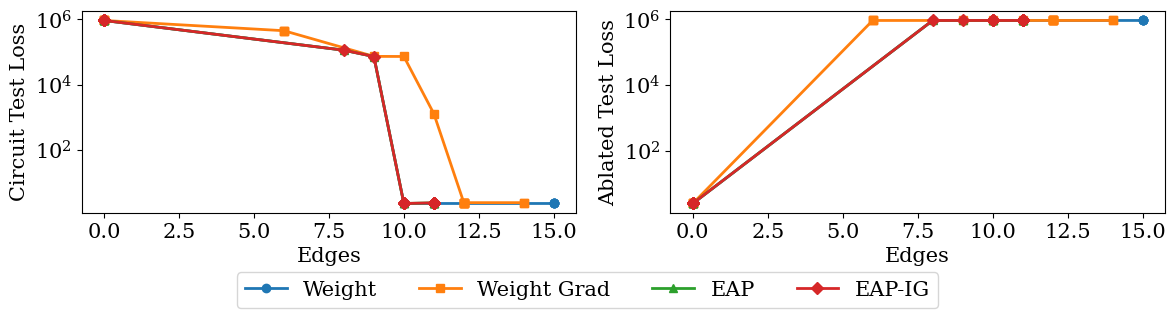

In [30]:
score_methods_plot = ['Weight', 'Weight Grad', 'EAP', 'EAP-IG']
markers = ['o', 's', '^', 'D']

plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'serif'
plt.rcParams['lines.linewidth'] = 2
fig, ax = plt.subplots(1,2, figsize=(12,3))
for score, score_plot in zip(score_methods, score_methods_plot):
    ax[0].plot(actual_edge_count[score], circuit_test_losses[score], label=score_plot, marker=markers[score_methods_plot.index(score_plot)])
    ax[1].plot(actual_edge_count[score], ablated_circuit_test_losses[score], marker=markers[score_methods_plot.index(score_plot)])

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('Edges')
ax[1].set_xlabel('Edges')
ax[0].set_ylabel('Circuit Test Loss')
ax[1].set_ylabel('Ablated Test Loss')
fig.legend(bbox_to_anchor=(.5, -.1), loc='lower center', ncol=4)
fig.tight_layout()

plt.savefig(f'../images/circuits_bellman_ford_edge_count_seed_{seed}.pdf', bbox_inches='tight')
plt.savefig(f'../images/circuits_bellman_ford_edge_count_seed_{seed}.png', dpi=300, bbox_inches='tight')
plt.show()